# Comparison Plots

Cross-model comparison visualizations for Qwen2.5-7B and Qwen3.5-9B NER experiments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import math

# Load results
res_25 = pd.read_csv("results/results_qwen25_7b.csv")
res_35 = pd.read_csv("results/results_qwen35_9b.csv")

# Load training loss logs
loss_25 = pd.read_csv("results/log_loss/qwen25_7b_training_loss.csv")
loss_35 = pd.read_csv("results/log_loss/qwen35_9b_training_loss.csv")

# Categorize results
def categorize_result(row):
    exp = row["experiment"]
    if exp in ("zero_shot", "few_shot"):
        return "Baseline"
    elif exp.startswith("generic_"):
        return "Generic only"
    elif exp.startswith("domain_"):
        return "Domain only"
    elif exp.startswith("seq_"):
        return "Sequential"
    elif exp.startswith("mix_"):
        return "Mixed"

for df in [res_25, res_35]:
    df["category"] = df.apply(categorize_result, axis=1)
    df["total_n"] = df["generic_n"] + df["domain_n"]

print(f"Qwen2.5-7B: {len(res_25)} experiments, {len(loss_25)} loss log rows")
print(f"Qwen3.5-9B: {len(res_35)} experiments, {len(loss_35)} loss log rows")

Qwen2.5-7B: 16 experiments, 143 loss log rows
Qwen3.5-9B: 16 experiments, 143 loss log rows


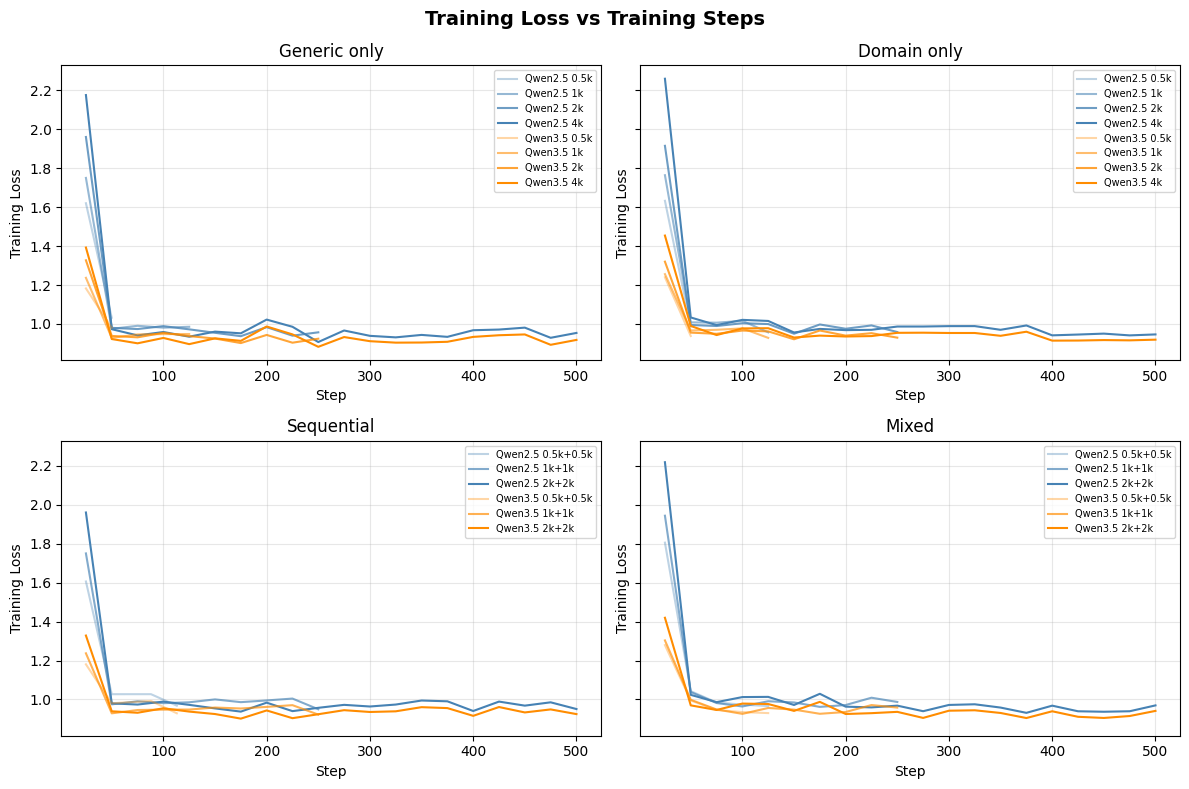

In [2]:
# --- Plot 1: Training Loss vs Training Steps (2x2 subplots by category) ---

SIZE_MAP = {"0.5k": 500, "1k": 1000, "2k": 2000, "4k": 4000}

def parse_size(exp_name):
    """Return (n1, n2) sample counts. n2 is None for single-phase."""
    if "+" in exp_name:
        parts = exp_name.split("+")
        s1 = parts[0].strip().split()[-1]
        s2 = parts[1].strip()
        return SIZE_MAP[s1], SIZE_MAP[s2]
    else:
        return SIZE_MAP[exp_name.split()[-1]], None

def get_loss_category(exp_name):
    if "\u2192" in exp_name:
        return "Sequential"
    elif exp_name.startswith("Mixed"):
        return "Mixed"
    elif exp_name.startswith("Generic"):
        return "Generic only"
    elif exp_name.startswith("Domain"):
        return "Domain only"

def add_step_col(df):
    """For sequential experiments, offset phase2 steps so the x-axis is continuous."""
    adj_steps = []
    for _, row in df.iterrows():
        n1, n2 = parse_size(row["experiment"])
        if row["phase"] == "phase2_domain":
            adj_steps.append(math.ceil(n1 / 8) + row["step"])
        else:
            adj_steps.append(row["step"])
    df["adj_step"] = adj_steps
    df["category"] = df["experiment"].apply(get_loss_category)
    return df

loss_25e = add_step_col(loss_25.copy())
loss_35e = add_step_col(loss_35.copy())

categories = ["Generic only", "Domain only", "Sequential", "Mixed"]
model_colors = {"Qwen2.5": "steelblue", "Qwen3.5": "darkorange"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle("Training Loss vs Training Steps", fontsize=14, fontweight="bold")

for ax, cat in zip(axes.flat, categories):
    ax.set_title(cat, fontsize=12)
    ax.set_xlabel("Step")
    ax.set_ylabel("Training Loss")
    ax.grid(True, alpha=0.3)

    for loss_df, model_name in [(loss_25e, "Qwen2.5"), (loss_35e, "Qwen3.5")]:
        cat_df = loss_df[loss_df["category"] == cat]
        experiments = cat_df["experiment"].unique()

        # Sort by total sample count
        exp_sizes = []
        for exp in experiments:
            n1, n2 = parse_size(exp)
            exp_sizes.append((exp, (n1 + n2) if n2 is not None else n1))
        exp_sizes.sort(key=lambda x: x[1])

        n_exp = len(exp_sizes)
        alphas = np.linspace(0.35, 1.0, n_exp)

        for i, (exp, total) in enumerate(exp_sizes):
            exp_data = cat_df[cat_df["experiment"] == exp].sort_values("adj_step")
            size_label = exp.split()[-1]
            ax.plot(exp_data["adj_step"], exp_data["training_loss"],
                    color=model_colors[model_name], alpha=alphas[i],
                    label=f"{model_name} {size_label}", linewidth=1.5)

    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
fig.savefig("plots/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

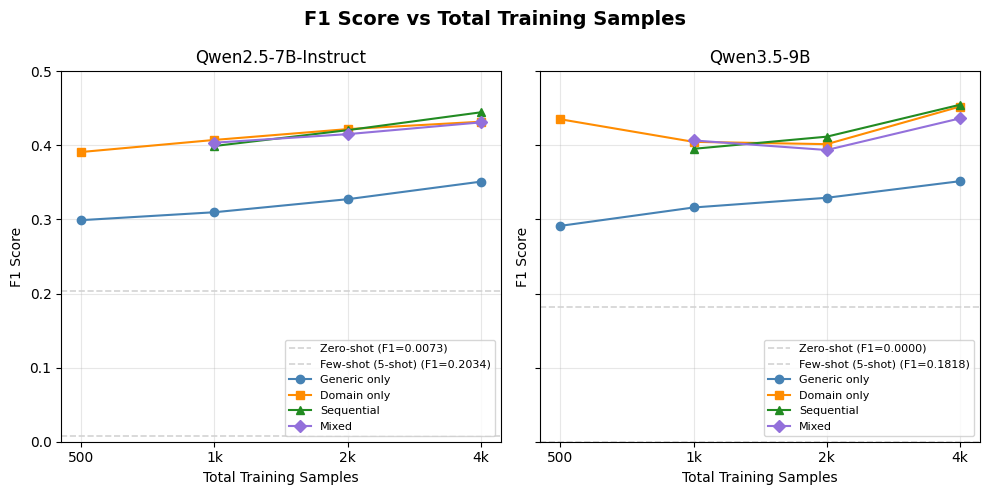

In [3]:
# --- Plot 2: F1 vs Total Training Samples ---

cat_styles = {
    "Generic only": ("steelblue", "o"),
    "Domain only": ("darkorange", "s"),
    "Sequential": ("forestgreen", "^"),
    "Mixed": ("mediumpurple", "D"),
}

# Map total_n to k where total_n = 1000 * 2^k
def n_to_k(n):
    return np.log2(n / 1000)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
fig.suptitle("F1 Score vs Total Training Samples", fontsize=14, fontweight="bold")

for ax, (df, title) in zip(axes, [(res_25, "Qwen2.5-7B-Instruct"), (res_35, "Qwen3.5-9B")]):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Total Training Samples")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 0.5)
    ax.grid(True, alpha=0.3)

    # Baselines as horizontal dashed lines
    baselines = df[df["category"] == "Baseline"]
    for _, row in baselines.iterrows():
        ax.axhline(y=row["f1"], color="lightgray", linestyle="--", linewidth=1.2,
                    label=f'{row["description"]} (F1={row["f1"]:.4f})')

    # Plot each category with k on x-axis
    for cat, (color, marker) in cat_styles.items():
        cat_df = df[df["category"] == cat].sort_values("total_n")
        if len(cat_df) > 0:
            k_vals = n_to_k(cat_df["total_n"])
            ax.plot(k_vals, cat_df["f1"],
                    color=color, marker=marker, label=cat, linewidth=1.5, markersize=6)

    # Set x-ticks at k = -1, 0, 1, 2 with labels 500, 1k, 2k, 4k
    k_ticks = [-1, 0, 1, 2]
    k_labels = ["500", "1k", "2k", "4k"]
    ax.set_xticks(k_ticks)
    ax.set_xticklabels(k_labels)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
fig.savefig("plots/f1_vs_training_size.png", dpi=150, bbox_inches="tight")
plt.show()

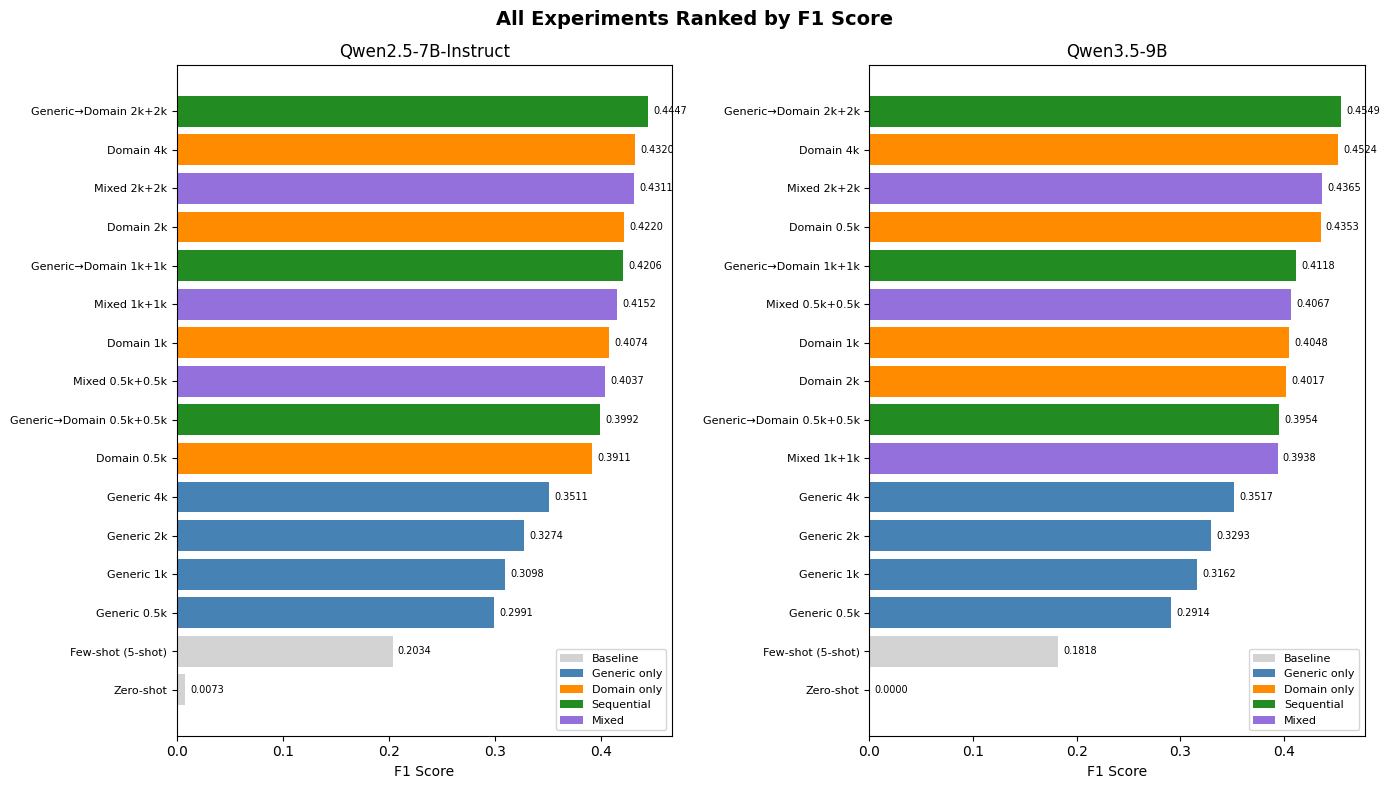

In [4]:
# --- Plot 3: Ranking Bar Charts ---

bar_colors = {
    "Baseline": "lightgray",
    "Generic only": "steelblue",
    "Domain only": "darkorange",
    "Sequential": "forestgreen",
    "Mixed": "mediumpurple",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.suptitle("All Experiments Ranked by F1 Score", fontsize=14, fontweight="bold")

for ax, (df, title) in zip(axes, [(res_25, "Qwen2.5-7B-Instruct"), (res_35, "Qwen3.5-9B")]):
    sorted_df = df.sort_values("f1", ascending=True)
    colors = [bar_colors[c] for c in sorted_df["category"]]
    ax.barh(range(len(sorted_df)), sorted_df["f1"], color=colors)
    ax.set_yticks(range(len(sorted_df)))
    ax.set_yticklabels(sorted_df["description"], fontsize=8)
    ax.set_xlabel("F1 Score")
    ax.set_title(title, fontsize=12)

    # Value labels
    for i, (_, row) in enumerate(sorted_df.iterrows()):
        ax.text(row["f1"] + 0.005, i, f'{row["f1"]:.4f}', va="center", fontsize=7)

    # Legend
    legend_elements = [Patch(facecolor=c, label=cat) for cat, c in bar_colors.items()]
    ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.tight_layout()
fig.savefig("plots/ranking_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()

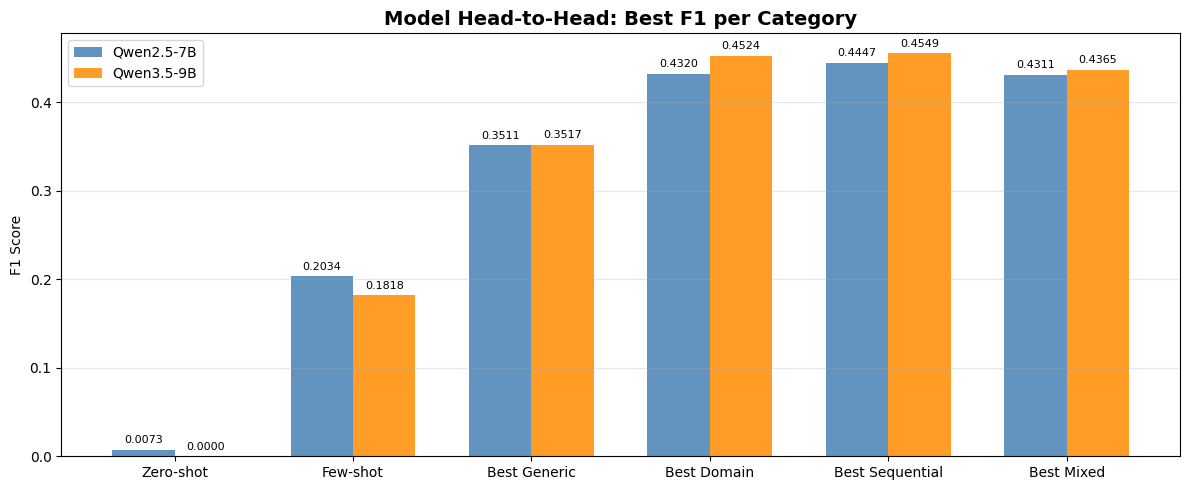

In [5]:
# --- Plot 4: Model Head-to-Head Comparison ---

labels = []
f1_25_vals = []
f1_35_vals = []

# Zero-shot and Few-shot
for exp_id, label in [("zero_shot", "Zero-shot"), ("few_shot", "Few-shot")]:
    labels.append(label)
    f1_25_vals.append(res_25.loc[res_25["experiment"] == exp_id, "f1"].values[0])
    f1_35_vals.append(res_35.loc[res_35["experiment"] == exp_id, "f1"].values[0])

# Best per category
for cat, label in [("Generic only", "Best Generic"), ("Domain only", "Best Domain"),
                   ("Sequential", "Best Sequential"), ("Mixed", "Best Mixed")]:
    labels.append(label)
    f1_25_vals.append(res_25.loc[res_25["category"] == cat, "f1"].max())
    f1_35_vals.append(res_35.loc[res_35["category"] == cat, "f1"].max())

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width / 2, f1_25_vals, width, label="Qwen2.5-7B", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width / 2, f1_35_vals, width, label="Qwen3.5-9B", color="darkorange", alpha=0.85)

ax.set_ylabel("F1 Score")
ax.set_title("Model Head-to-Head: Best F1 per Category", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

# Label bars with F1 values
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig.savefig("plots/head_to_head.png", dpi=150, bbox_inches="tight")
plt.show()